Using device: cuda


Fetching 122 files:   0%|          | 0/122 [00:00<?, ?it/s]

Found 2 archive(s): ['download_lamem.tar.gz', 'memnet.tar.gz']
  download_lamem.tar.gz already extracted, skipping
  memnet.tar.gz already extracted, skipping
Total JPGs found: 58741
DATA_DIR: lamem_hf/lamem
splits:   lamem_hf/lamem/splits  (15 files)
Score entries in splits: 58741
Images with scores AND files present: 58741
Using 10000 images  (requested N=10000, available=58741)
ResNet-50 loaded on cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias      

CLIP ViT-B/16 loaded on cuda
  200/10000  elapsed=11.2s  eta=546.9s
  400/10000  elapsed=22.2s  eta=532.2s
  600/10000  elapsed=33.7s  eta=528.4s
  800/10000  elapsed=45.1s  eta=518.3s
  1000/10000  elapsed=55.8s  eta=502.2s
  1200/10000  elapsed=67.9s  eta=498.0s
  1400/10000  elapsed=84.4s  eta=518.5s
  1600/10000  elapsed=96.3s  eta=505.5s
  1800/10000  elapsed=107.4s  eta=489.0s
  2000/10000  elapsed=118.6s  eta=474.4s
  2200/10000  elapsed=129.1s  eta=457.9s
  2400/10000  elapsed=140.4s  eta=444.5s
  2600/10000  elapsed=151.3s  eta=430.6s
  2800/10000  elapsed=162.8s  eta=418.6s
  3000/10000  elapsed=174.0s  eta=405.9s
  3200/10000  elapsed=184.9s  eta=392.9s
  3400/10000  elapsed=195.9s  eta=380.3s
  3600/10000  elapsed=206.2s  eta=366.6s
  3800/10000  elapsed=217.1s  eta=354.1s
  4000/10000  elapsed=228.4s  eta=342.6s
  4200/10000  elapsed=239.5s  eta=330.7s
  4400/10000  elapsed=250.2s  eta=318.4s
  4600/10000  elapsed=261.0s  eta=306.4s
  4800/10000  elapsed=272.2s  eta=294.8s

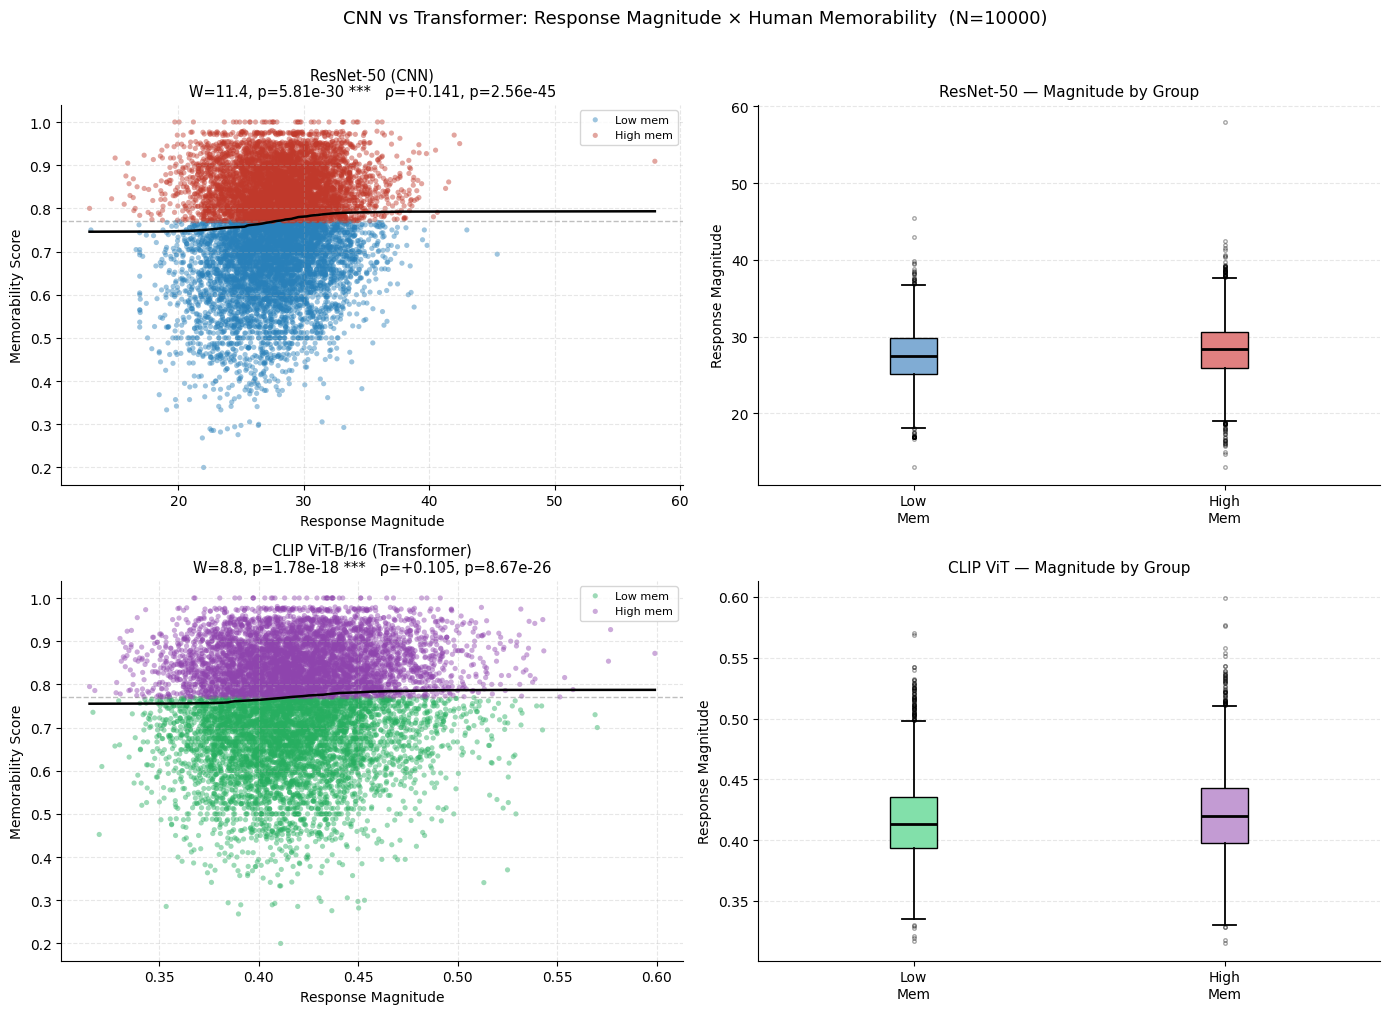

Saved: fig1_wilcoxon.png


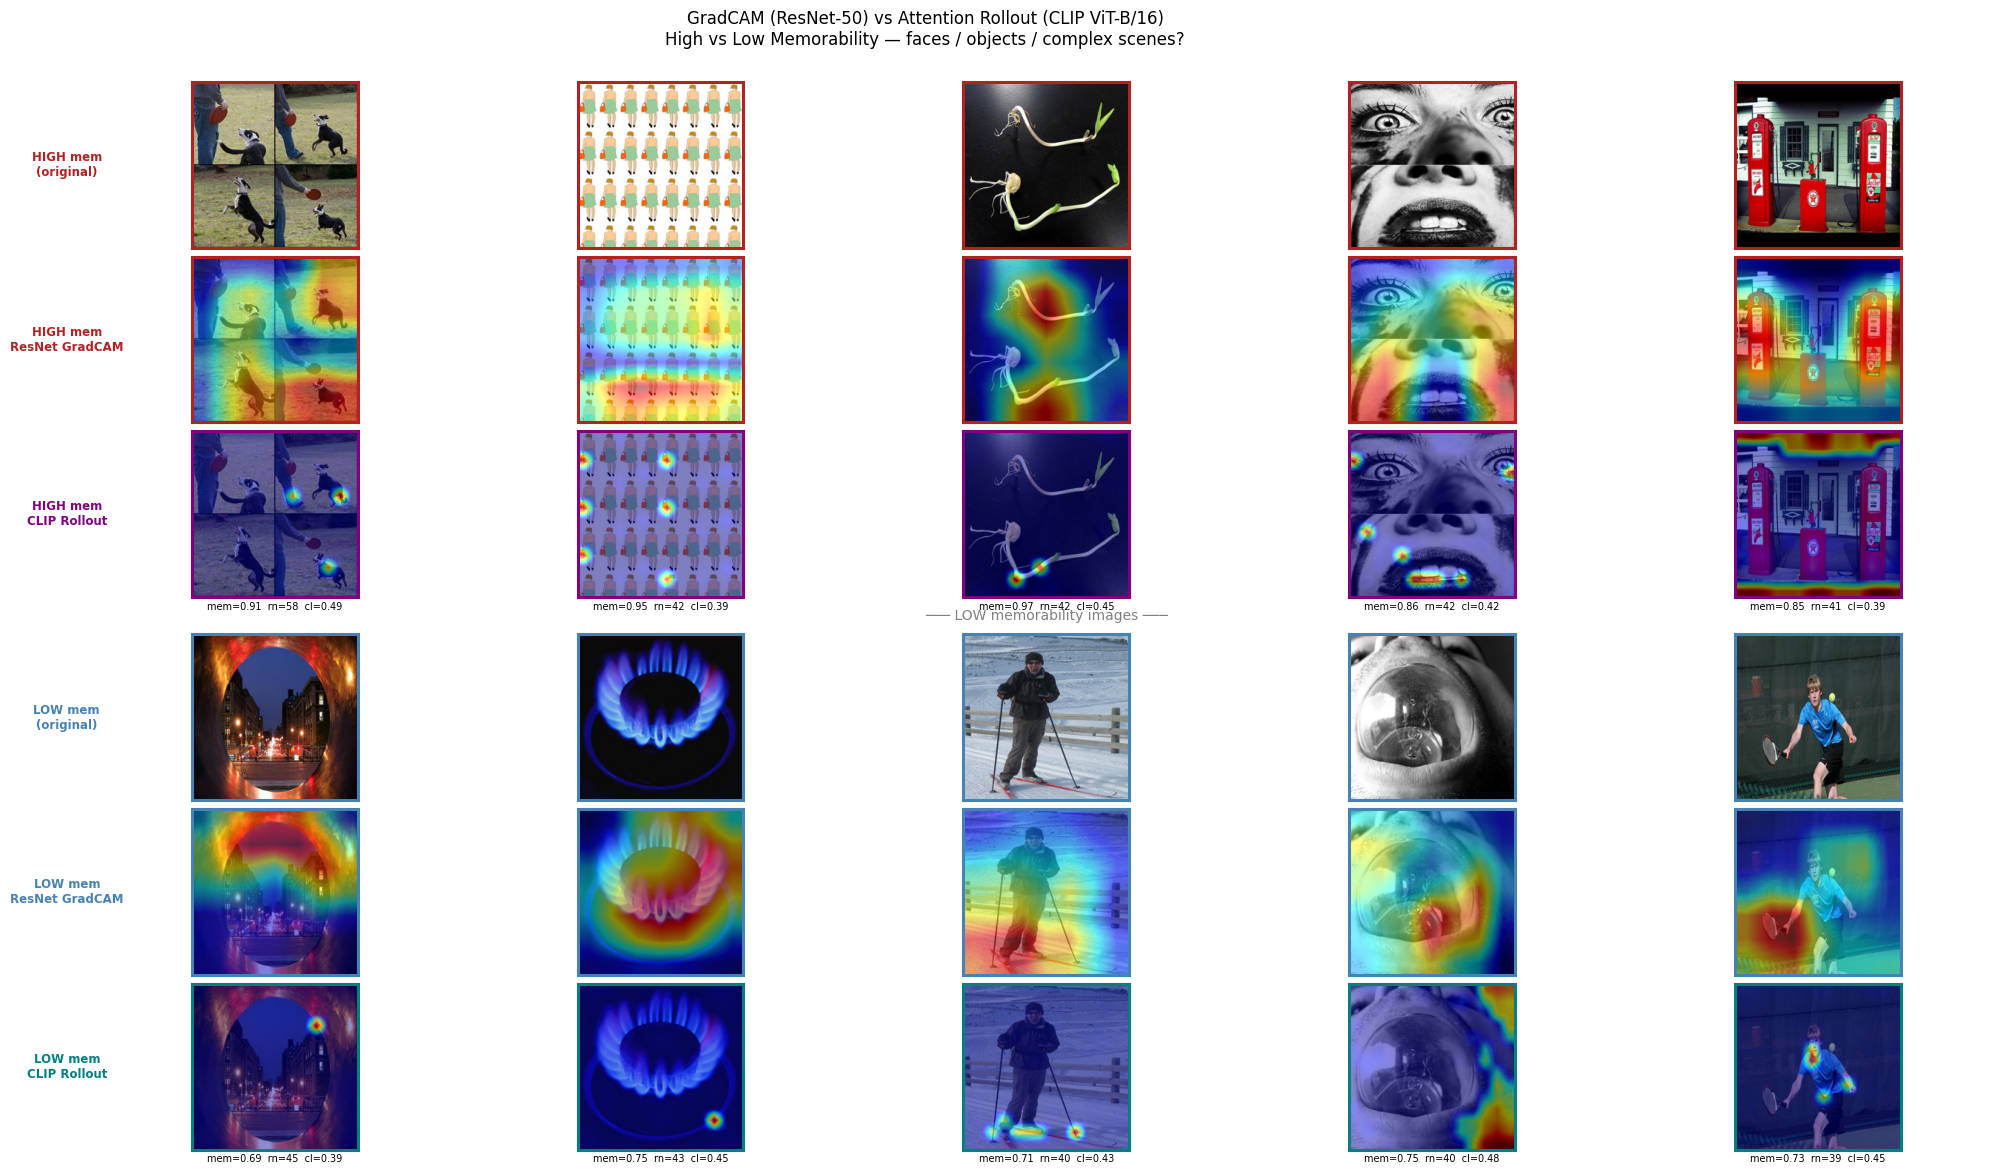

Saved: fig2_gradcam_rollout.png


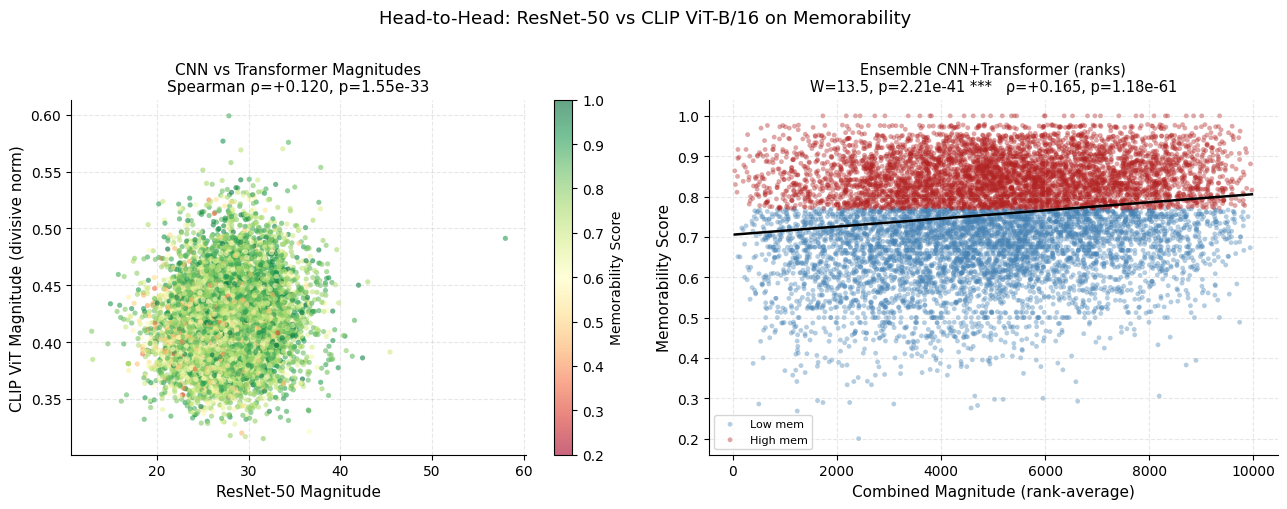

Saved: fig3_model_comparison.png

Model                        High med    Low med        W     p (Wilc)   sig   ρ(mag,mem)        p (ρ)
--------------------------------------------------------------------------------------------
ResNet-50 (CNN)                28.307     27.438    11.37    5.812e-30   ***       +0.141    2.565e-45
CLIP ViT-B/16 (Transf.)         0.419      0.414     8.77    1.775e-18   ***       +0.105    8.666e-26
Ensemble (rank-avg)          5283.000   4650.000    13.47    2.205e-41   ***       +0.165    1.182e-61

ResNet–CLIP cross-model agreement:  Spearman ρ=+0.120, p=1.553e-33

N analysed: 10000  (full LaMem = 58,741 images)

Notes:
  • All correlations are Spearman (rank-based) — appropriate for non-Gaussian,
    skewed magnitudes (L2 norms, ratios) and for the bounded memorability score.
  • Ensemble combines models by rank-averaging, not z-scoring, so heavy tails
    in either magnitude distribution cannot dominate the combined score.


In [ ]:
# ============================================================
# CELL 1 — install (run once per Colab session)
# ============================================================
!pip install -q grad-cam huggingface_hub scipy matplotlib torchvision pandas pillow transformers

# ============================================================
# CELL 2 — all imports
# ============================================================
from pathlib import Path
import tarfile
import time
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from scipy import stats
from scipy.stats import rankdata, spearmanr            # NEW: rank tools
from torchvision import models, transforms
from transformers import CLIPImageProcessor, CLIPVisionModel
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from huggingface_hub import snapshot_download

# GPU device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cpu':
    print("⚠️  No GPU detected — switch: Runtime → Change runtime type → T4 GPU")

# ============================================================
# CELL 3 — download, extract tarball, and build score → path map
# ============================================================
TARGET_N = 10000

snapshot_download(
    repo_id="chitradrishti/LAMEM",
    repo_type="dataset",
    local_dir="lamem_hf"
)

base = Path('lamem_hf')

# --- Find and extract any .tar.gz archives ---
archives = list(base.rglob('*.tar.gz'))
print(f"Found {len(archives)} archive(s): {[a.name for a in archives]}")

for archive in archives:
    extract_flag = base / (archive.stem.replace('.tar', '') + '_EXTRACTED')
    if extract_flag.exists():
        print(f"  {archive.name} already extracted, skipping")
        continue
    print(f"  Extracting {archive.name} ({archive.stat().st_size / 1e9:.2f} GB) ...")
    t_ex = time.time()
    with tarfile.open(archive, 'r:gz') as tf:
        tf.extractall(path=base)
    extract_flag.touch()
    print(f"  Extracted in {time.time() - t_ex:.1f}s")

all_jpgs = sorted(base.rglob('*.jpg'))
print(f"Total JPGs found: {len(all_jpgs)}")

candidates = [p for p in base.rglob('splits') if p.is_dir()]
assert len(candidates) >= 1, f"No splits/ directory found in {base}"
DATA_DIR = candidates[0].parent
split_dir = DATA_DIR / 'splits'
print(f"DATA_DIR: {DATA_DIR}")
print(f"splits:   {split_dir}  ({len(list(split_dir.glob('*.txt')))} files)")

scores_df = pd.concat([
    pd.read_csv(f, sep=' ', header=None, names=['filename', 'mem_score', 'std'])
    for f in sorted(split_dir.glob('*.txt'))
]).drop_duplicates('filename').reset_index(drop=True)
print(f"Score entries in splits: {len(scores_df)}")

name_to_path = {}
for p in all_jpgs:
    name_to_path[p.name] = p
    name_to_path['images/' + p.name] = p
    try:
        name_to_path[str(p.relative_to(DATA_DIR))] = p
    except ValueError:
        pass

def resolve(f):
    return (name_to_path.get(f)
         or name_to_path.get(Path(f).name)
         or name_to_path.get('images/' + Path(f).name))

scores_df['path'] = scores_df['filename'].map(resolve)
available = scores_df.dropna(subset=['path'])
print(f"Images with scores AND files present: {len(available)}")

n = min(TARGET_N, len(available))
sample = available.sample(n, random_state=42).reset_index(drop=True)
print(f"Using {n} images  (requested N={TARGET_N}, available={len(available)})")

# ============================================================
# CELL 4 — load ResNet-50 (on GPU)
# ============================================================
resnet = models.resnet50(weights='IMAGENET1K_V1').to(device)
resnet.eval()

resnet_activation = {}
def _resnet_hook(module, inp, out):
    resnet_activation['layer4'] = out.detach()
resnet_hook = resnet.layer4.register_forward_hook(_resnet_hook)

resnet_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
print("ResNet-50 loaded on", device)

# ============================================================
# CELL 5 — load CLIP ViT-B/16 with eager attention (on GPU)
# ============================================================
clip_processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch16")
clip_model = CLIPVisionModel.from_pretrained(
    "openai/clip-vit-base-patch16",
    attn_implementation='eager'
).to(device)
clip_model.eval()
print("CLIP ViT-B/16 loaded on", device)

# ============================================================
# CELL 6 — extract magnitudes for both models
# ============================================================
t0 = time.time()
resnet_mags, clip_mags, mem_scores, paths_used, errors = [], [], [], [], []

for idx, row in sample.iterrows():
    try:
        img_path = row['path']
        img_pil  = Image.open(img_path).convert('RGB')

        # ResNet-50 — L2 norm of spatially-averaged layer4
        x = resnet_tf(img_pil).unsqueeze(0).to(device)
        with torch.no_grad():
            resnet(x)
        act        = resnet_activation['layer4'].squeeze(0)
        resnet_mag = act.mean(dim=[1, 2]).norm(p=2).item()

        # CLIP ViT — divisive normalisation: CLS / mean spatial patch norm
        inputs = clip_processor(images=img_pil, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            clip_out = clip_model(**inputs, output_hidden_states=True)
        last_hs       = clip_out.hidden_states[-1].squeeze(0)
        cls_mag       = last_hs[0].norm(p=2).item()
        mean_spat_mag = last_hs[1:].norm(p=2, dim=1).mean().item()
        clip_mag      = cls_mag / (mean_spat_mag + 1e-5)

        resnet_mags.append(resnet_mag)
        clip_mags.append(clip_mag)
        mem_scores.append(row['mem_score'])
        paths_used.append(img_path)

        if (idx + 1) % 200 == 0:
            el  = time.time() - t0
            eta = el / (idx + 1) * (len(sample) - idx - 1)
            print(f"  {idx+1}/{len(sample)}  elapsed={el:.1f}s  eta={eta:.1f}s")

    except Exception as e:
        errors.append((str(row['path']), str(e)))
        if len(errors) <= 3:
            print(f"  ERROR: {row['path']} — {e}")

resnet_hook.remove()

resnet_mags = np.array(resnet_mags)
clip_mags   = np.array(clip_mags)
mem_scores  = np.array(mem_scores)
paths_used  = np.array(paths_used)
print(f"\nSuccessful: {len(resnet_mags)}  |  Failed: {len(errors)}  |  Time: {time.time()-t0:.1f}s")

# ============================================================
# CELL 7 — Wilcoxon rank-sum tests + Spearman ρ vs memorability
# ============================================================
median_score = np.median(mem_scores)
high_mask    = mem_scores >= median_score
low_mask     = mem_scores <  median_score

def wilcoxon_stats(mags, label):
    W, p = stats.ranksums(mags[high_mask], mags[low_mask])
    sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    rho, p_rho = spearmanr(mags, mem_scores)              # NEW: rank correlation with mem score
    print(f"[{label}]  high_med={np.median(mags[high_mask]):.3f}  "
          f"low_med={np.median(mags[low_mask]):.3f}  "
          f"W={W:.2f}  p={p:.3e}  {sig}   "
          f"|  Spearman ρ(mag, mem)={rho:+.3f}  p={p_rho:.2e}")
    return W, p, sig, rho, p_rho

print(f"\nMedian memorability split: {median_score:.3f}")
rn_W, rn_p, rn_sig, rn_rho, rn_p_rho = wilcoxon_stats(resnet_mags, "ResNet-50    ")
cl_W, cl_p, cl_sig, cl_rho, cl_p_rho = wilcoxon_stats(clip_mags,   "CLIP ViT-B/16")

# ============================================================
# CELL 8 — GradCAM (ResNet) + Attention Rollout (CLIP ViT)
# ============================================================
cam = GradCAM(model=resnet, target_layers=[resnet.layer4[-1]])

def get_gradcam(img_path):
    img_pil = Image.open(img_path).convert('RGB').resize((224, 224))
    img_np  = np.array(img_pil).astype(np.float32) / 255.0
    input_t = resnet_tf(img_pil).unsqueeze(0).to(device)
    gc      = cam(input_tensor=input_t, targets=None)
    return img_np, show_cam_on_image(img_np, gc[0], use_rgb=True)

def attention_rollout(img_pil, discard_ratio=0.9):
    """Propagates CLS attention across all 12 ViT layers."""
    layer_attns = []

    def _hook(module, inp, out):
        if isinstance(out, tuple) and len(out) > 1 and out[1] is not None:
            layer_attns.append(out[1].detach().cpu())

    hooks = [layer.self_attn.register_forward_hook(_hook)
             for layer in clip_model.vision_model.encoder.layers]

    inputs = clip_processor(images=img_pil, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        clip_model(**inputs, output_attentions=True)
    for h in hooks:
        h.remove()

    if not layer_attns:
        return None

    rollout = torch.eye(197)
    for attn in layer_attns:
        a = attn.squeeze(0).mean(0)
        a = a / (a.sum(dim=-1, keepdim=True) + 1e-8)
        flat   = a.flatten()
        thresh = flat.kthvalue(int(len(flat) * discard_ratio)).values
        a[a < thresh] = 0
        a = a / (a.sum(dim=-1, keepdim=True) + 1e-8)
        rollout = a @ rollout

    cls_row = rollout[0, 1:]
    cls_row = (cls_row - cls_row.min()) / (cls_row.max() - cls_row.min() + 1e-8)
    return cls_row.reshape(14, 14).numpy()

def overlay_rollout(img_pil, sal14):
    img_np = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.0
    sal_up = F.interpolate(
        torch.tensor(sal14).unsqueeze(0).unsqueeze(0).float(),
        size=(224, 224), mode='bilinear', align_corners=False
    ).squeeze().numpy()
    sal_up = (sal_up - sal_up.min()) / (sal_up.max() - sal_up.min() + 1e-8)
    return img_np, show_cam_on_image(img_np, sal_up, use_rgb=True)

high_idx = np.where(high_mask)[0]
low_idx  = np.where(low_mask)[0]
top_high = high_idx[np.argsort(resnet_mags[high_idx])[::-1]][:5]
top_low  = low_idx[ np.argsort(resnet_mags[low_idx]) [::-1]][:5]

print(f"Generating visualisations for {len(top_high)} high + {len(top_low)} low images …")

def collect_vis(indices):
    orig, rn_ov, cl_ov, sc, rm, cm = [], [], [], [], [], []
    for i in indices:
        path    = paths_used[i]
        img_pil = Image.open(path).convert('RGB')
        o, ro   = get_gradcam(path)
        sal     = attention_rollout(img_pil.resize((224, 224)))
        _, co   = overlay_rollout(img_pil, sal) if sal is not None else (o, o.copy())
        orig.append(o);  rn_ov.append(ro); cl_ov.append(co)
        sc.append(mem_scores[i]); rm.append(resnet_mags[i]); cm.append(clip_mags[i])
    return orig, rn_ov, cl_ov, sc, rm, cm

high_orig, high_rn, high_cl, high_sc, high_rm, high_cm = collect_vis(top_high)
low_orig,  low_rn,  low_cl,  low_sc,  low_rm,  low_cm  = collect_vis(top_low)
print("Visualisations ready.")

# ============================================================
# CELL 9 — Figure 1: Wilcoxon scatter + boxplots (2×2)
#          Title now also reports Spearman ρ(mag, mem)
# ============================================================
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))

def scatter_panel(ax, mags, W, p, sig, rho, p_rho, title, ch, cl_):
    ax.scatter(mags[low_mask],  mem_scores[low_mask],
               s=14, alpha=0.45, color=cl_, edgecolors='none', label='Low mem')
    ax.scatter(mags[high_mask], mem_scores[high_mask],
               s=14, alpha=0.45, color=ch,  edgecolors='none', label='High mem')
    ax.axhline(median_score, color='grey', lw=1, ls='--', alpha=0.5)
    # Visual trendline computed in rank space → matches Spearman geometry
    rk_x = rankdata(mags); rk_y = rankdata(mem_scores)
    m_, b_ = np.polyfit(rk_x, rk_y, 1)
    xl_rank = np.linspace(rk_x.min(), rk_x.max(), 200)
    order_x = np.argsort(mags); order_y = np.argsort(mem_scores)
    ax.plot(np.interp(xl_rank, rk_x[order_x], mags[order_x]),
            np.interp(m_*xl_rank + b_, rk_y[order_y], mem_scores[order_y]),
            color='black', lw=1.8)
    ax.set_title(f'{title}\nW={W:.1f}, p={p:.2e} {sig}   '
                 f'ρ={rho:+.3f}, p={p_rho:.2e}', fontsize=10.5)
    ax.set_xlabel('Response Magnitude', fontsize=10)
    ax.set_ylabel('Memorability Score', fontsize=10)
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
    ax.grid(ls='--', alpha=0.3)

def box_panel(ax, mags, title, ch, cl_):
    bp = ax.boxplot([mags[low_mask], mags[high_mask]],
                    labels=['Low\nMem','High\nMem'], patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(lw=1.3), capprops=dict(lw=1.3),
                    flierprops=dict(marker='o', ms=2.5, alpha=0.35))
    bp['boxes'][0].set_facecolor(cl_)
    bp['boxes'][1].set_facecolor(ch)
    ax.set_ylabel('Response Magnitude', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', ls='--', alpha=0.3)

scatter_panel(axes[0,0], resnet_mags, rn_W, rn_p, rn_sig, rn_rho, rn_p_rho,
              'ResNet-50 (CNN)', '#c0392b', '#2980b9')
box_panel    (axes[0,1], resnet_mags,
              'ResNet-50 — Magnitude by Group', '#e08080', '#80acd4')
scatter_panel(axes[1,0], clip_mags, cl_W, cl_p, cl_sig, cl_rho, cl_p_rho,
              'CLIP ViT-B/16 (Transformer)', '#8e44ad', '#27ae60')
box_panel    (axes[1,1], clip_mags,
              'CLIP ViT — Magnitude by Group', '#c39bd3', '#82e0aa')

fig1.suptitle(f'CNN vs Transformer: Response Magnitude × Human Memorability  (N={len(resnet_mags)})',
              fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_wilcoxon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_wilcoxon.png")

# ============================================================
# CELL 10 — Figure 2: GradCAM vs Attention Rollout panel
#           (unchanged — purely visual)
# ============================================================
N_VIS = 5
fig2  = plt.figure(figsize=(22, 12))
gs    = gridspec.GridSpec(7, N_VIS, figure=fig2,
                          hspace=0.06, wspace=0.04,
                          top=0.91, bottom=0.02, left=0.12, right=0.99,
                          height_ratios=[1,1,1,0.12,1,1,1])

rows = [
    (0, high_orig, 'HIGH mem\n(original)',      'firebrick', False),
    (1, high_rn,   'HIGH mem\nResNet GradCAM',  'firebrick', False),
    (2, high_cl,   'HIGH mem\nCLIP Rollout',    'purple',    True),
    (4, low_orig,  'LOW mem\n(original)',        'steelblue', False),
    (5, low_rn,    'LOW mem\nResNet GradCAM',   'steelblue', False),
    (6, low_cl,    'LOW mem\nCLIP Rollout',     'teal',      True),
]
for (ri, imgs, lbl, col, show_sc) in rows:
    sc_list = high_sc if 'HIGH' in lbl else low_sc
    rm_list = high_rm if 'HIGH' in lbl else low_rm
    cm_list = high_cm if 'HIGH' in lbl else low_cm
    for ci in range(N_VIS):
        ax = fig2.add_subplot(gs[ri, ci])
        ax.imshow(imgs[ci]); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(col); sp.set_linewidth(2.2)
        if ci == 0:
            ax.set_ylabel(lbl, fontsize=8.5, rotation=0,
                          labelpad=90, va='center',
                          color=col, fontweight='bold')
        if show_sc:
            ax.set_xlabel(
                f"mem={sc_list[ci]:.2f}  rn={rm_list[ci]:.0f}  cl={cm_list[ci]:.2f}",
                fontsize=7, labelpad=3)

sep = fig2.add_subplot(gs[3, :])
sep.axis('off')
sep.text(0.5, 0.5, '─── LOW memorability images ───',
         ha='center', va='center', fontsize=10,
         color='grey', transform=sep.transAxes)

fig2.suptitle(
    'GradCAM (ResNet-50) vs Attention Rollout (CLIP ViT-B/16)\n'
    'High vs Low Memorability — faces / objects / complex scenes?',
    fontsize=12, y=0.97)
plt.savefig('fig2_gradcam_rollout.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_gradcam_rollout.png")

# ============================================================
# CELL 11 — Figure 3: head-to-head model comparison
#           Pearson  → Spearman
#           z-score  → rank averaging
# ============================================================
fig3, ax3 = plt.subplots(1, 2, figsize=(13, 5))

# --- LEFT: cross-model magnitude relationship (Spearman) -----
sc = ax3[0].scatter(resnet_mags, clip_mags, c=mem_scores,
                    cmap='RdYlGn', s=14, alpha=0.6, edgecolors='none')
plt.colorbar(sc, ax=ax3[0], label='Memorability Score')
rho_cc, p_cc = spearmanr(resnet_mags, clip_mags)            # was: pearsonr
ax3[0].set_xlabel('ResNet-50 Magnitude', fontsize=11)
ax3[0].set_ylabel('CLIP ViT Magnitude (divisive norm)', fontsize=11)
ax3[0].set_title(f'CNN vs Transformer Magnitudes\n'
                 f'Spearman ρ={rho_cc:+.3f}, p={p_cc:.2e}', fontsize=11)
ax3[0].spines[['top','right']].set_visible(False)
ax3[0].grid(ls='--', alpha=0.3)

# --- RIGHT: rank-averaged ensemble (was z-score average) -----
rn_rk = rankdata(resnet_mags)
cl_rk = rankdata(clip_mags)
combo = (rn_rk + cl_rk) / 2.0                                # rank-average ensemble

W_e, p_e       = stats.ranksums(combo[high_mask], combo[low_mask])
sig_e          = "***" if p_e < 0.001 else ("**" if p_e < 0.01 else ("*" if p_e < 0.05 else "n.s."))
rho_e, p_e_rho = spearmanr(combo, mem_scores)

ax3[1].scatter(combo[low_mask],  mem_scores[low_mask],
               s=12, alpha=0.4, color='steelblue', edgecolors='none', label='Low mem')
ax3[1].scatter(combo[high_mask], mem_scores[high_mask],
               s=12, alpha=0.4, color='firebrick',  edgecolors='none', label='High mem')
m_e, b_e = np.polyfit(combo, mem_scores, 1)
xl_e = np.linspace(combo.min(), combo.max(), 200)
ax3[1].plot(xl_e, m_e*xl_e + b_e, color='black', lw=1.8)
ax3[1].set_xlabel('Combined Magnitude (rank-average)', fontsize=11)
ax3[1].set_ylabel('Memorability Score', fontsize=11)
ax3[1].set_title(f'Ensemble CNN+Transformer (ranks)\n'
                 f'W={W_e:.1f}, p={p_e:.2e} {sig_e}   '
                 f'ρ={rho_e:+.3f}, p={p_e_rho:.2e}', fontsize=10.5)
ax3[1].legend(fontsize=8)
ax3[1].spines[['top','right']].set_visible(False)
ax3[1].grid(ls='--', alpha=0.3)

fig3.suptitle('Head-to-Head: ResNet-50 vs CLIP ViT-B/16 on Memorability', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_model_comparison.png")

# ============================================================
# CELL 12 — summary table  (now reports Spearman ρ too)
# ============================================================
print("\n" + "="*92)
print(f"{'Model':<26} {'High med':>10} {'Low med':>10} {'W':>8} {'p (Wilc)':>12} "
      f"{'sig':>5} {'ρ(mag,mem)':>12} {'p (ρ)':>12}")
print("-"*92)
for lbl, mags, W, p, sig, rho, p_rho in [
    ("ResNet-50 (CNN)",          resnet_mags, rn_W, rn_p, rn_sig, rn_rho, rn_p_rho),
    ("CLIP ViT-B/16 (Transf.)",  clip_mags,   cl_W, cl_p, cl_sig, cl_rho, cl_p_rho),
    ("Ensemble (rank-avg)",       combo,       W_e,  p_e,  sig_e,  rho_e,  p_e_rho),
]:
    print(f"{lbl:<26} {np.median(mags[high_mask]):>10.3f} {np.median(mags[low_mask]):>10.3f} "
          f"{W:>8.2f} {p:>12.3e} {sig:>5} {rho:>+12.3f} {p_rho:>12.3e}")
print("="*92)
print(f"\nResNet–CLIP cross-model agreement:  Spearman ρ={rho_cc:+.3f}, p={p_cc:.3e}")
print(f"\nN analysed: {len(resnet_mags)}  (full LaMem = 58,741 images)")
print("\nNotes:")
print("  • All correlations are Spearman (rank-based) — appropriate for non-Gaussian,")
print("    skewed magnitudes (L2 norms, ratios) and for the bounded memorability score.")
print("  • Ensemble combines models by rank-averaging, not z-scoring, so heavy tails")
print("    in either magnitude distribution cannot dominate the combined score.")